# Layer 3–4: Student Video Segmentation & Alignment

Processes a student video end-to-end:
1. Load extracted poses (`chon_ji_student_poses.json`)
2. Normalize + extract joint angles (Layer 2)
3. Segment via `segment_student_video()` — velocity valleys + keypose matching (Layer 3)
4. Align to master via `align_with_gaps()` + `validate_alignment()` (Layer 4)
5. Visualize and optionally export overlay video

**Prerequisite**: Run Layer 1 pose extraction first (see `01_pose_extraction.ipynb` or run extractor directly).
The JSON file should exist at `sample_videos/chon_ji_student_poses.json`.

In [77]:
import sys
import pathlib

project_root = pathlib.Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"project_root: {project_root}")

project_root: E:\Projects\Saas\Taekwon


In [ ]:
import warnings
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itf_analysis.segmentation.segmentor import load_poses_from_json
from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.keypose_matcher import load_master_keyposes
from itf_analysis.segmentation.velocity_detector import compute_motion_velocity, smooth_velocity
from itf_analysis.segmentation.segmenter import segment_movements
from itf_analysis.alignment.gap_aligner import align_with_gaps, validate_alignment

# ── Change only this section when testing a new video ───────────────────────
POOMSAE            = "chon_ji"    # folder name under master_data/ and sample_videos/
STUDENT_NAME       = "student2"   # filename (without extension) inside sample_videos/{POOMSAE}/
STUDENT_START_FRAME = 0           # first frame of actual poomsae content (after ready stance)
STUDENT_END_FRAME  = 934          # last frame of poomsae content (excluding return-to-ready)
                                   # set to None to use full video, then adjust after reviewing overlay
# ─────────────────────────────────────────────────────────────────────────────

sample_dir         = project_root / "itf_analysis" / "sample_videos"
poomsae_dir        = sample_dir / POOMSAE
STUDENT_VIDEO_PATH = str(poomsae_dir / f"{STUDENT_NAME}.mp4")
STUDENT_POSES_PATH = str(poomsae_dir / f"{STUDENT_NAME}_poses.json")
KEYPOSES_PATH      = str(project_root / "itf_analysis" / "master_data" / POOMSAE / "keyposes_angles.json")

CONF_COLOR  = {"high": "green",   "medium": "orange", "low": "red"}
MATCH_COLOR = {"matched": "#2ecc71", "skipped": "#e74c3c", "extra": "#f1c40f"}

print(f"Video : {STUDENT_VIDEO_PATH}")
print(f"Poses : {STUDENT_POSES_PATH}")
print(f"End frame: {STUDENT_END_FRAME}")

## Step 1: Load keyposes + student angles

## Step 0: Pose extraction (run only for a new video)

To test a new student video:
1. Copy the MP4 file to `STUDENT_VIDEO_PATH`
2. Run the cell below (~5-10 minutes)
3. Skip if the JSON file already exists

In [79]:
import os
from itf_analysis.pose_extraction.extractor import (
    extract_poses_from_video, interpolate_missing_landmarks, save_poses_to_json
)

if os.path.exists(STUDENT_POSES_PATH):
    print(f"JSON already exists — skipping extraction.")
    print(f"  {STUDENT_POSES_PATH}")
    print(f"  Delete this file to force re-extraction.")
else:
    print(f"Extracting poses from: {STUDENT_VIDEO_PATH}")
    frames = extract_poses_from_video(STUDENT_VIDEO_PATH)
    frames = interpolate_missing_landmarks(frames)
    save_poses_to_json(frames, STUDENT_POSES_PATH)
    print("Done.")

JSON already exists — skipping extraction.
  E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\chon_ji_student2_poses.json
  Delete this file to force re-extraction.


In [80]:
# Master keyposes (19 angle dicts)
keyposes = load_master_keyposes(KEYPOSES_PATH)
print(f"Keyposes loaded: {len(keyposes)} / 19")

# Student poses → angles
frames = load_poses_from_json(STUDENT_POSES_PATH)
student_fps = 1000.0 / (frames[1].timestamp_ms - frames[0].timestamp_ms) if len(frames) > 1 else 30.0

student_angles = []
for f in frames:
    norm = normalize_pose(f.landmarks)
    if norm is None:
        continue
    student_angles.append((f.frame_index, extract_joint_angles(norm)))

print(f"Student: {len(frames)} frames  fps={student_fps:.1f}  angle frames={len(student_angles)}")

Keyposes loaded: 19 / 19
Student: 964 frames  fps=30.0  angle frames=964


## Step 2: Segment student video

In [81]:

# ── Diagnostics: how many valleys, and what are the distances? ────────────────
from itf_analysis.segmentation.velocity_detector import find_velocity_valleys
from itf_analysis.segmentation.keypose_matcher import keypose_distance

velocity_diag = compute_motion_velocity(student_angles, student_fps)
smoothed_diag = smooth_velocity(velocity_diag, student_fps)
valleys_diag  = find_velocity_valleys(smoothed_diag, student_fps, min_gap_sec=0.5)
fi_all = [f for f, _ in student_angles]

print(f"Total velocity valleys detected: {len(valleys_diag)}")
print()

# For each valley, show best-matching keypose distance
angles_lkp = {f: a for f, a in student_angles}
print(f"{'Valley frame':>13} {'best_mov':>9} {'best_dist°':>11} {'2nd_dist°':>11}")
print("-" * 50)
for v in valleys_diag:
    fi = fi_all[v]
    fa = angles_lkp.get(fi)
    if fa is None:
        continue
    dists = sorted(
        [(kp["movement_index"], keypose_distance(fa, kp["angles"])) for kp in keyposes],
        key=lambda x: x[1]
    )
    m1, d1 = dists[0]
    m2, d2 = dists[1] if len(dists) > 1 else (0, 0)
    marker = " ← matched" if d1 < 25.0 else ""
    print(f"{fi:>13} {m1:>9} {d1:>11.1f} {d2:>11.1f}{marker}")


Total velocity valleys detected: 25

 Valley frame  best_mov  best_dist°   2nd_dist°
--------------------------------------------------
            6        19        10.4        10.4 ← matched
           56        12         8.2        15.3 ← matched
          101         7        21.3        22.8 ← matched
          149         3        12.5        20.8 ← matched
          176         3        16.7        20.0 ← matched
          197         7        14.9        16.8 ← matched
          242         5        12.1        14.2 ← matched
          289         6        18.9        20.0 ← matched
          338         7        19.3        26.3 ← matched
          385         8        18.6        22.6 ← matched
          410        11         6.6         7.4 ← matched
          432        11        16.6        20.2 ← matched
          481         3         9.1        20.1 ← matched
          530        11         7.3        11.3 ← matched
          579        12        10.5        18.8 ← ma

In [82]:
from itf_analysis.segmentation.segmenter import segment_movements

# Strip source_frames so segment_movements() uses adaptive rolling expected
keyposes_no_src = [{k: v for k, v in kp.items() if k != "source_frame"} for kp in keyposes]

# Last frame of actual poomsae content — return-to-ready starts after this.
# Verified: valley at frame 1156 = movement 19 completion.
# 1219 (total) - 1156 = 63 frames = 2.1s return-to-ready → reasonable.
# Adjust this if overlay video shows the last movement ends at a different frame.
STUDENT_END_FRAME = 934

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    boundaries = segment_movements(
        student_angles,
        keyposes_no_src,
        fps=student_fps,
        start_frame=STUDENT_START_FRAME,
        end_frame=STUDENT_END_FRAME,
    )

print(f"Detected: {len(boundaries)} / 19 movements")
if caught:
    for w in caught:
        print(f"  WARNING: {w.message}")

print(f"\n{'Mov':>4} {'frame':>6} {'time_ms':>9} {'conf':>8}  signals")
print("-" * 55)
for b in boundaries:
    print(f"{b.movement_number:>4} {b.frame:>6} {b.timestamp_ms:>9.0f} "
          f"{b.confidence:>8}  {b.matched_signals}")

dist = Counter(b.confidence for b in boundaries)
print(f"\nConfidence: high={dist['high']}  medium={dist['medium']}  low={dist['low']}")


Detected: 19 / 19 movements

 Mov  frame   time_ms     conf  signals
-------------------------------------------------------
   1     56      1867   medium  ['velocity', 'keypose']
   2    101      3367   medium  ['velocity', 'keypose']
   3    149      4967   medium  ['velocity', 'keypose']
   4    197      6567   medium  ['velocity']
   5    242      8067   medium  ['velocity', 'keypose']
   6    289      9633   medium  ['velocity', 'keypose']
   7    338     11267   medium  ['velocity', 'keypose']
   8    385     12833   medium  ['velocity', 'keypose']
   9    432     14400   medium  ['velocity', 'keypose']
  10    481     16033   medium  ['velocity']
  11    530     17667     high  ['velocity', 'keypose']
  12    579     19300     high  ['velocity', 'keypose']
  13    623     20767     high  ['velocity', 'keypose']
  14    674     22467   medium  ['velocity']
  15    719     23967     high  ['velocity', 'keypose']
  16    770     25667   medium  ['velocity', 'keypose']
  17    815 

## Step 3: Velocity curve with detected boundaries

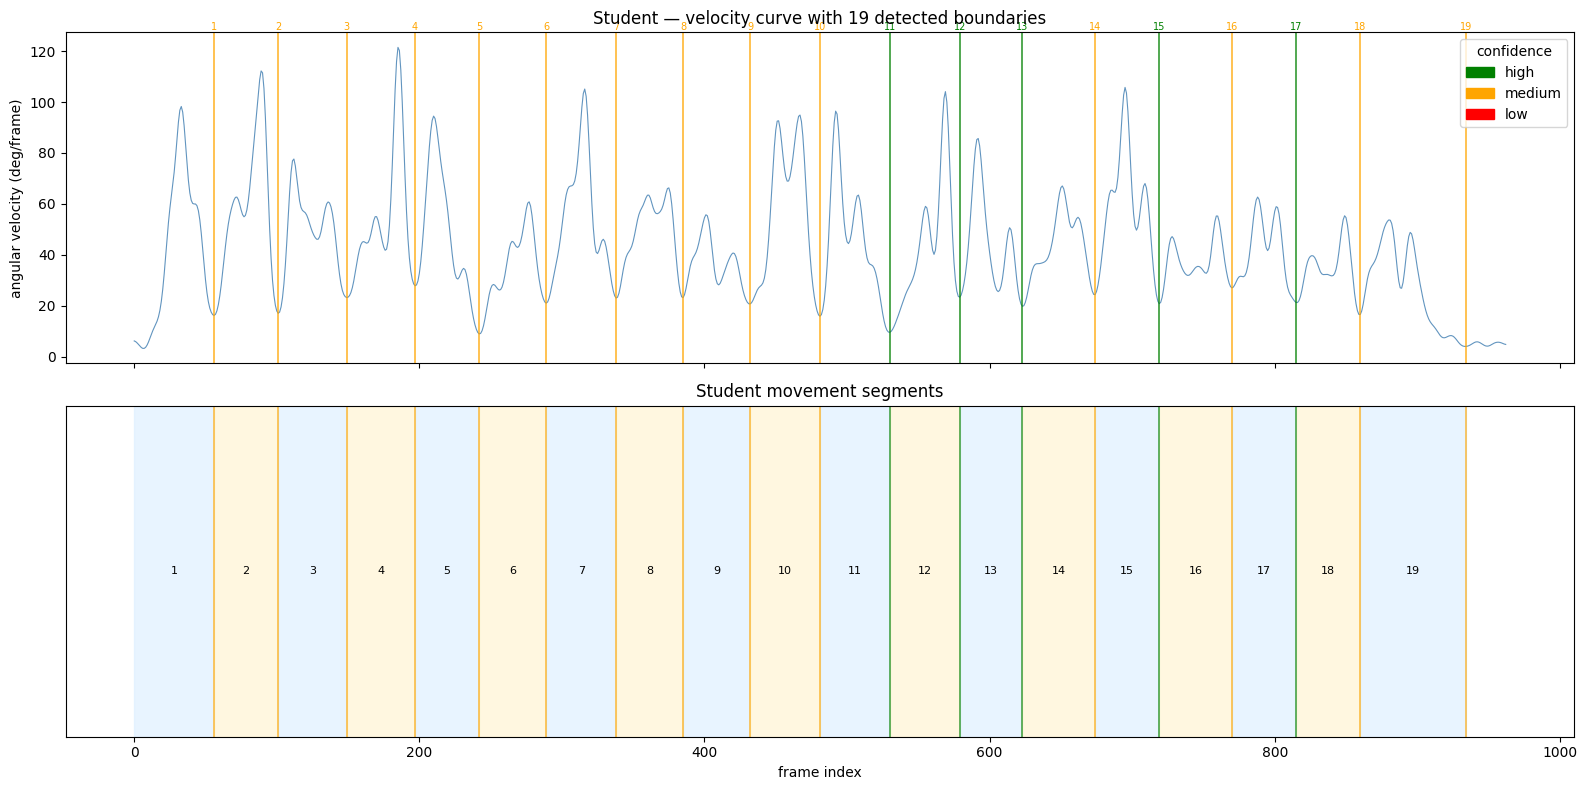

In [83]:
velocity = compute_motion_velocity(student_angles, student_fps)
smoothed = smooth_velocity(velocity, student_fps)
fi = np.array([f for f, _ in student_angles[:len(smoothed)]])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: velocity curve + boundaries
axes[0].plot(fi, smoothed, linewidth=0.8, color="steelblue", alpha=0.85)
for b in boundaries:
    col = CONF_COLOR[b.confidence]
    axes[0].axvline(b.frame, color=col, linewidth=1.2, alpha=0.8)
    axes[0].text(b.frame, axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 1,
                 str(b.movement_number), ha="center", va="bottom", fontsize=7, color=col)
patches = [mpatches.Patch(color=c, label=l) for l, c in CONF_COLOR.items()]
axes[0].legend(handles=patches, title="confidence", loc="upper right")
axes[0].set_ylabel("angular velocity (deg/frame)")
axes[0].set_title(f"Student — velocity curve with {len(boundaries)} detected boundaries")

# Bottom: movement bands
band_colors = ["#daeeff", "#fff3cc"]
prev = 0
for b in boundaries:
    col = band_colors[(b.movement_number - 1) % 2]
    axes[1].axvspan(prev, b.frame, alpha=0.6, color=col)
    axes[1].text((prev + b.frame) / 2, 0.5, str(b.movement_number),
                 ha="center", va="center", fontsize=8)
    axes[1].axvline(b.frame, color=CONF_COLOR[b.confidence], linewidth=1.2, alpha=0.7)
    prev = b.frame
axes[1].set_yticks([])
axes[1].set_xlabel("frame index")
axes[1].set_title("Student movement segments")

plt.tight_layout()
plt.show()

## Step 4: Align to master + validate

In [84]:
pairs = align_with_gaps(keyposes, boundaries)

print(f"{'Master':>7} {'Student':>8} {'Match Type':>12} {'Confidence':>11}")
print("-" * 44)
MATCH_SYMBOL = {"matched": "✓", "skipped": "✗", "extra": "→"}
for p in pairs:
    master_str  = str(p.master_movement) if p.master_movement is not None else "-"
    student_str = str(p.student_boundary.movement_number) if p.student_boundary else "-"
    conf_str    = p.student_boundary.confidence if p.student_boundary else "-"
    sym         = MATCH_SYMBOL[p.match_type]
    print(f"{master_str:>7} {student_str:>8} {p.match_type:>12}  {conf_str:>10}  {sym}")

result = validate_alignment(pairs)
status = "✓ VALID" if result.valid else "✗ INVALID"
print(f"\nStatus  : {status}")
print(f"Message : {result.message or '(none — clean)'}")
print(f"Skipped : {result.skipped_movements or 'none'}")
print(f"Extra   : {result.extra_count}")

 Master  Student   Match Type  Confidence
--------------------------------------------
      1        1      matched      medium  ✓
      2        2      matched      medium  ✓
      3        3      matched      medium  ✓
      4        4      matched      medium  ✓
      5        5      matched      medium  ✓
      6        6      matched      medium  ✓
      7        7      matched      medium  ✓
      8        8      matched      medium  ✓
      9        9      matched      medium  ✓
     10       10      matched      medium  ✓
     11       11      matched        high  ✓
     12       12      matched        high  ✓
     13       13      matched        high  ✓
     14       14      matched      medium  ✓
     15       15      matched        high  ✓
     16       16      matched      medium  ✓
     17       17      matched        high  ✓
     18       18      matched      medium  ✓
     19       19      matched      medium  ✓

Status  : ✓ VALID
Message : (none — clean)
Skipped : none

## Step 5: Alignment timeline

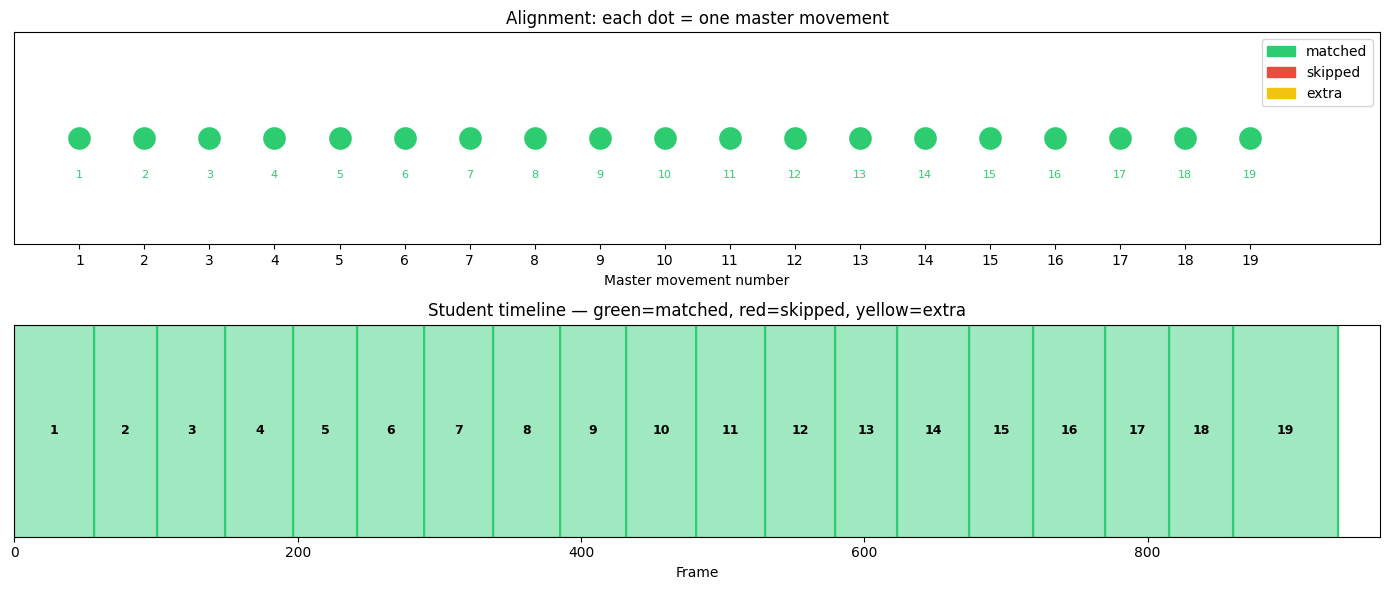

Summary: matched=19  skipped=0  extra=0


In [85]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Top: dot plot per master movement
ax = axes[0]
for p in pairs:
    x = p.master_movement if p.master_movement is not None else 19.5
    col = MATCH_COLOR[p.match_type]
    ax.scatter(x, 1, s=300, color=col, zorder=3, edgecolors="white", linewidths=1)
    ax.text(x, 0.85, str(x), ha="center", va="top", fontsize=8, color=col)
ax.set_xlim(0, 21)
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
ax.set_xticks(range(1, 20))
ax.set_xlabel("Master movement number")
ax.set_title("Alignment: each dot = one master movement")
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in MATCH_COLOR.items()]
ax.legend(handles=legend_patches, loc="upper right")

# Bottom: student timeline
ax2 = axes[1]
total_frames = student_angles[-1][0] + 1
boundary_match = {p.student_boundary.frame: p.match_type for p in pairs if p.student_boundary}
prev = 0
for b in boundaries:
    mt = boundary_match.get(b.frame, "extra")
    col = MATCH_COLOR[mt]
    ax2.axvspan(prev, b.frame, alpha=0.45, color=col)
    ax2.axvline(b.frame, color=col, lw=1.5)
    ax2.text((prev + b.frame) / 2, 0.5, str(b.movement_number),
             ha="center", va="center", fontsize=9, fontweight="bold")
    prev = b.frame
skipped_movs = [p.master_movement for p in pairs if p.match_type == "skipped"]
for mov in skipped_movs:
    exp_x = round(mov / 19 * total_frames)
    ax2.axvline(exp_x, color="#e74c3c", lw=2, linestyle="--", alpha=0.7)
    ax2.text(exp_x, 0.85, f"M{mov}\nmissing", ha="center", va="top",
             fontsize=7, color="#e74c3c")
ax2.set_xlim(0, total_frames)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_xlabel("Frame")
ax2.set_title("Student timeline — green=matched, red=skipped, yellow=extra")

plt.tight_layout()
plt.show()

matched_n = sum(1 for p in pairs if p.match_type == "matched")
skipped_n = sum(1 for p in pairs if p.match_type == "skipped")
extra_n   = sum(1 for p in pairs if p.match_type == "extra")
print(f"Summary: matched={matched_n}  skipped={skipped_n}  extra={extra_n}")

## Step 6: Overlay video (optional)

Exports an annotated MP4 with movement number and confidence per frame.

In [86]:
import os

def create_overlay_video(video_path, boundaries, output_path):
    try:
        import cv2
    except ImportError:
        print("OpenCV not available.")
        return
    if not os.path.exists(video_path):
        print(f"Video not found: {video_path}")
        return

    cap = cv2.VideoCapture(video_path)
    fps_v = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Input : {video_path}  ({w}x{h}  {fps_v:.1f}fps  {total} frames)")

    frame_map = {}
    prev = 0
    for b in boundaries:
        for f in range(prev, b.frame + 1):
            frame_map[f] = (b.movement_number, b.confidence)
        prev = b.frame + 1

    BGR = {"high": (0, 200, 0), "medium": (0, 165, 255), "low": (0, 0, 220)}
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps_v, (w, h))

    fi = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        info = frame_map.get(fi)
        if info:
            mov_num, conf = info
            color = BGR.get(conf, (200, 200, 200))
            cv2.rectangle(frame, (8, 8), (260, 80), (20, 20, 20), -1)
            cv2.rectangle(frame, (8, 8), (260, 80), color, 2)
            cv2.putText(frame, f"Mov {mov_num:02d} / 19",
                        (18, 44), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            cv2.putText(frame, conf.upper(),
                        (18, 72), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 1)
            bar_w = int(w * mov_num / 19)
            cv2.rectangle(frame, (0, h - 8), (bar_w, h), color, -1)
        out.write(frame)
        fi += 1

    cap.release()
    out.release()
    print(f"Saved : {output_path}")


overlay_path = str(sample_dir / f"{STUDENT_NAME}_segmented.mp4")
create_overlay_video(STUDENT_VIDEO_PATH, boundaries, overlay_path)

Input : E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\chon_ji_student2.mp4  (1920x1080  30.0fps  964 frames)
Saved : E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\chon_ji_student2_segmented.mp4
